# 패키지 및 데이터 로드

In [29]:
# ── 사용자 정의 모듈
from hossam import *
# ── 표준 라이브러리
import numpy as np

# ── 서드파티 라이브러리
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame

# ── 머신러닝 (scikit-learn)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor




 > 지도학습 > 예측 > 앙상블 >  Boosting

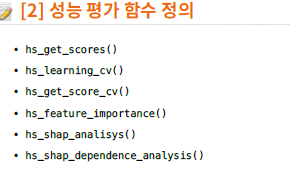<br>


### 데이터 가져오기 + 인덱스, 타입변환

In [32]:
origin = load_data("restaurant_sales_preprocessed")
origin.head()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)


,date,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
0,2024-01-01,16.169,122,14490,9.200,0.480,1.946,5.200,0,0
1,2024-01-02,16.005,106,11880,9.149,0.480,2.079,11.100,0,0
2,2024-01-03,16.354,120,18010,8.666,0.430,2.595,12.900,1,0
3,2024-01-04,16.082,115,11160,8.748,0.410,2.028,12.900,0,0
4,2024-01-05,16.113,124,15480,8.594,0.510,2.197,11.000,0,0


In [33]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()



어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


In [7]:
# 원본 데이터
df = origin

# 타깃 / 피처 분리
y_name = "sales"
X = df.drop(columns=y_name)
y = df[y_name]

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52,
)

# 데이터 크기 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((273, 10), (92, 10), (273,), (92,))

### 베이스 모델에 대한 성능평가 표

In [34]:
score_df = DataFrame(
    [
        [
            "Linear",
            0.709, 0.156, 0.042, 0.204, 0.010, 0.225,
            0.198, 0.203, 0.012, 0.973, 0.060,
            "⚠️ 과대적합",
        ],
        [
            "Ridge",
            0.708, 0.156, 0.042, 0.205, 0.010, 0.219,
            0.198, 0.203, 0.012, 0.974, 0.058,
            "⚠️ 과대적합",
        ],
        [
            "Lasso",
            0.707, 0.155, 0.042, 0.205, 0.009, 0.221,
            0.199, 0.204, 0.011, 0.978, 0.055,
            "⚠️ 과대적합",
        ],
        [
            "ElasticNet",
            0.709, 0.156, 0.042, 0.204, 0.010, 0.223,
            0.198, 0.203, 0.012, 0.974, 0.059,
            "⚠️ 과대적합",
        ],
        [
            "SGD",
            0.700, 0.160, 0.043, 0.207, 0.010, 0.229,
            0.203, 0.210, 0.010, 0.964, 0.046,
            "⚠️ 과대적합",
        ],
        [
            "KNN",
            0.635, 0.178, 0.052, 0.229, 0.011, 0.301,
            0.000, 0.220, 0.009, 0.000, 0.090,
            "⚠️ 과대적합 (variance 큼)",
        ],
        [
            "DecisionTree",
            0.620, 0.196, 0.054, 0.233, 0.012, 0.353,
            0.224, 0.245, 0.018, 0.912, 0.072,
            "✅ 일반화 양호",
        ],
        [
            "SVR",
            0.701, 0.157, 0.043, 0.207, 0.010, 0.233,
            0.196, 0.206, 0.011, 0.949, 0.055,
            "✅ 일반화 양호",
        ],
    ],
    columns=[
        "모델",
        "결정계수(R2)",
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "MPE",
        "Train RMSE",
        "CV RMSE 평균",
        "CV RMSE 표준편차",
        "Train/CV 비율",
        "CV 변동성 비율",
        "판정 결과",
    ],
)

score_df


,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
0,Linear,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 과대적합
1,Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 과대적합
2,Lasso,0.707,0.155,0.042,0.205,0.009,0.221,0.199,0.204,0.011,0.978,0.055,⚠️ 과대적합
3,ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 과대적합
4,SGD,0.700,0.160,0.043,0.207,0.010,0.229,0.203,0.210,0.010,0.964,0.046,⚠️ 과대적합
5,KNN,0.635,0.178,0.052,0.229,0.011,0.301,0.000,0.220,0.009,0.000,0.090,⚠️ 과대적합 (variance 큼)
6,DecisionTree,0.620,0.196,0.054,0.233,0.012,0.353,0.224,0.245,0.018,0.912,0.072,✅ 일반화 양호
7,SVR,0.701,0.157,0.043,0.207,0.010,0.233,0.196,0.206,0.011,0.949,0.055,✅ 일반화 양호


### Boosting 우선순위 정렬 기준

In [35]:
# ── 기준값 정의
MAX_CV_VARIABILITY = 0.02      # CV 변동성 상한
MIN_TRAIN_CV_RATIO = 0.85      # Train/CV 비율 하한
MAX_TRAIN_CV_RATIO = 1.05      # Train/CV 비율 상한

LINEAR_MODELS = [
    "Linear",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "SGD",
]

# ── 원본 보호
boosting_df = score_df.copy()

# ── (1) 과도한 변동성 모델 제거
boosting_df = boosting_df[
    boosting_df["CV RMSE 표준편차"] <= MAX_CV_VARIABILITY
]

# ── (2) Train / CV 괴리 기준 필터링
boosting_df = boosting_df[
    (boosting_df["Train/CV 비율"] >= MIN_TRAIN_CV_RATIO)
    & (boosting_df["Train/CV 비율"] <= MAX_TRAIN_CV_RATIO)
]

# ── (3) 성능 기준 정렬
# R2가 낮을수록, CV RMSE 평균이 클수록 부스팅 개선 여지 ↑
boosting_df = boosting_df.sort_values(
    by=["결정계수(R2)", "CV RMSE 평균"],
    ascending=[True, True],
)

# ── (4) 선형 계열 모델 제거
boosting_df = boosting_df[
    ~boosting_df["모델"].isin(LINEAR_MODELS)
]

# ── 최종 후보 컬럼 선택
boosting_candidates = boosting_df[
    ["모델", "결정계수(R2)", "CV RMSE 평균", "Train/CV 비율", "CV RMSE 표준편차"]
].reset_index(drop=True)

boosting_candidates


,모델,결정계수(R2),CV RMSE 평균,Train/CV 비율,CV RMSE 표준편차
0,DecisionTree,0.620,0.245,0.912,0.018
1,SVR,0.701,0.206,0.949,0.011


### 최종 후보(Decision Tree)

In [43]:
type(df.index)


pandas.core.indexes.datetimes.DatetimeIndex

In [44]:
%%time

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# ====================================================
# 1. 데이터 준비
# ====================================================
df = origin.copy()

# 타깃
y = df["sales"]

# ❗ 핵심: DatetimeIndex 제거 (에러 원인 차단)
df = df.reset_index(drop=True)

# 피처
X = df.drop(columns="sales")

# ====================================================
# 2. 컬럼 구분
# ====================================================
num_cols = [
    "visitors",
    "avg_price",
    "marketing_cost",
    "delivery_ratio",
    "rain_mm",
    "temperature",
]

cat_cols = [
    "holiday",
    "weekend",
]

# ====================================================
# 3. 전처리기
# ====================================================
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# ====================================================
# 4. 모델
# ====================================================
dt = DecisionTreeRegressor(
    random_state=52
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", dt),
    ]
)

# ====================================================
# 5. 하이퍼파라미터 그리드
# ====================================================
param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__max_features": [None, "sqrt", "log2"],
    "model__criterion": ["squared_error", "absolute_error"],
}

# ====================================================
# 6. GridSearchCV
# ====================================================
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ====================================================
# 7. 학습
# ====================================================
gs.fit(X, y)

# ====================================================
# 8. 결과
# ====================================================
best_model = gs.best_estimator_

print("Best params:")
print(gs.best_params_)
print()
print("Best CV R2:", gs.best_score_)

best_model


Best params:
{'model__criterion': 'absolute_error', 'model__max_depth': 3, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}

Best CV R2: 0.6194843504228984
CPU times: total: 1.31 s
Wall time: 6.16 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### 주요 하이퍼파라미터

In [47]:
%%time

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# ====================================================
# 1. 데이터 준비
# ====================================================
df = origin.copy()

# DatetimeIndex 완전 제거 (핵심)
df = df.reset_index(drop=True)

# 타깃
y = df["sales"]

# 피처
X = df.drop(columns="sales")

# ====================================================
# 2. 컬럼 구분
# ====================================================
num_cols = [
    "visitors",
    "avg_price",
    "marketing_cost",
    "delivery_ratio",
    "rain_mm",
    "temperature",
]

cat_cols = [
    "holiday",
    "weekend",
]

# ====================================================
# 3. 전처리기 (숫자 + 범주형)
# ====================================================
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

# ====================================================
# 4. Train / Test split
# ====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52,
)

# ====================================================
# 5. Base Decision Tree (AdaBoost용)
# ⚠️ Pipeline 절대 아님 (여기가 이전 에러 원인)
# ====================================================
base_tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=52,
)

# ====================================================
# 6. AdaBoost 파이프라인
# ====================================================
ada_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            AdaBoostRegressor(
                estimator=base_tree,
                random_state=52,
            ),
        ),
    ]
)

# ====================================================
# 7. 하이퍼파라미터 그리드
# ====================================================
param_grid = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.3, 1.0],
    "model__loss": ["linear", "square", "exponential"],
}

# ====================================================
# 8. GridSearchCV
# ====================================================
gs_ada = GridSearchCV(
    estimator=ada_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ====================================================
# 9. 학습
# ====================================================
gs_ada.fit(X_train, y_train)

# ====================================================
# 10. 결과
# ====================================================
best_ada_model = gs_ada.best_estimator_

print("Best AdaBoost params:")
print(gs_ada.best_params_)
print()
print("Best CV R2:", gs_ada.best_score_)

best_ada_model


Best AdaBoost params:
{'model__learning_rate': 0.3, 'model__loss': 'square', 'model__n_estimators': 200}

Best CV R2: 0.6344041122127193
CPU times: total: 625 ms
Wall time: 7.57 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont